Model Evaluation.

Mounting the drive.

In [ ]:
import shutil, os
from google.colab import drive

# Remove the stale mountpoint contents
if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

drive.mount("/content/drive")

Mounted at /content/drive


Setting up dependencies

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaForSequenceClassification, RobertaTokenizer


Load model & tokenizer

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/DF_HateSpeech_Project"   # update if needed
MODEL_DIR   = os.path.join(PROJECT_DIR, "bert_3class_final")
OUTPUT_DIR  = os.path.join(PROJECT_DIR, "evaluation")

BATCH_SIZE  = 16
MAX_LEN     = 128

# Hard-coded class mapping — must match training order
CLASS2ID = {"hatespeech": 0, "normal": 1, "offensive": 2}
ID2CLASS  = {v: k for k, v in CLASS2ID.items()}
CLASSES   = [ID2CLASS[i] for i in range(len(ID2CLASS))]

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


Load Model from Directory

In [ ]:
assert os.path.exists(MODEL_DIR), f"Model directory not found: {MODEL_DIR}"

tokenizer = RobertaTokenizer.from_pretrained(MODEL_DIR)
model     = RobertaForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()
print(f"Model loaded from: {MODEL_DIR}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded from: /content/drive/MyDrive/DF_HateSpeech_Project/bert_3class_final


Load Test Dataset

In [ ]:
test_df = pd.read_csv(os.path.join(PROJECT_DIR, "test_processed.csv"))
print(f"Test samples: {len(test_df)}")
print(test_df.head())

Test samples: 1924
                       post_id  \
0  1179055004553900032_twitter   
1                 13851720_gab   
2  1178818409812746240_twitter   
3                 19346774_gab   
4  1165819983701643266_twitter   

                                                text       label  label_id  
0  i dont think im getting my baby them white 9 h...      normal         1  
1  laura loomer raped me while screaming at me in...  hatespeech         0  
2  <user> what did the old lady do was she a nazi...      normal         1  
3  as much as i appreciate a format of open discu...      normal         1  
4  sex be so good a bitch be slow stroking and cr...   offensive         2  


Define Dataset Class and Test DataLoader

In [ ]:
class HateSpeechDataset(Dataset):
    """Tokenises texts on the fly; returns tensors ready for the model."""

    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts     = df["text"].tolist()
        self.labels    = df["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


test_loader = DataLoader(
    HateSpeechDataset(test_df, tokenizer),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Evaluate Model on Test Set

In [ ]:
def evaluate(model, loader) -> tuple[list, list]:
    """Return (predictions, true_labels) for an entire DataLoader."""
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device),
            )
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_trues.extend(batch["labels"].numpy())
    return all_preds, all_trues


test_preds, test_trues = evaluate(model, test_loader)

accuracy = accuracy_score(test_trues, test_preds)
macro_f1 = f1_score(test_trues, test_preds, average="macro")

print(f"\nTest Accuracy : {accuracy:.4f}")
print(f"Test Macro-F1 : {macro_f1:.4f}")
print("\nClassification Report:")
print(classification_report(test_trues, test_preds, target_names=CLASSES))


Test Accuracy : 0.6809
Test Macro-F1 : 0.6708

Classification Report:
              precision    recall  f1-score   support

  hatespeech       0.72      0.80      0.76       594
      normal       0.77      0.70      0.73       782
   offensive       0.52      0.52      0.52       548

    accuracy                           0.68      1924
   macro avg       0.67      0.67      0.67      1924
weighted avg       0.68      0.68      0.68      1924



Plot Confusion Matrix

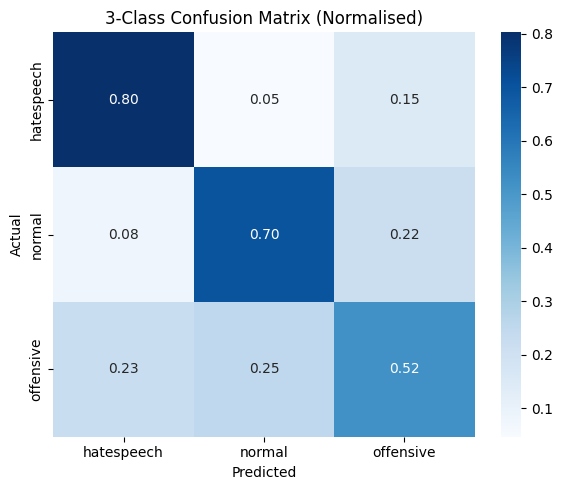

Confusion matrix saved to: /content/drive/MyDrive/DF_HateSpeech_Project/evaluation/confusion_matrix.png


In [ ]:
cm            = confusion_matrix(test_trues, test_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    cmap="Blues",
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("3-Class Confusion Matrix (Normalised)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to: {OUTPUT_DIR}/confusion_matrix.png")

Define Prediction Function

In [ ]:
def predict(text: str) -> dict:
    """
    Run inference on a single text string.

    Returns a dict with keys:
        text         – the original input
        prediction   – predicted class label (str)
        confidence   – probability of the predicted class (float)
        probabilities – per-class probability dict
    """
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    with torch.no_grad():
        logits = model(
            input_ids=encoding["input_ids"].to(device),
            attention_mask=encoding["attention_mask"].to(device),
        ).logits
    probs    = F.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))

    return {
        "text":          text,
        "prediction":    ID2CLASS[pred_idx],
        "confidence":    round(float(probs[pred_idx]), 4),
        "probabilities": {ID2CLASS[i]: round(float(probs[i]), 4) for i in range(len(probs))},
    }

Run Sample Predictions

In [ ]:
sample_texts = [
    "I love everyone in my community!",
    "I hate people from that group.",
    "You are so stupid!",
    "Those immigrants are ruining this country",
]

print("\nSample Inference:")
print("=" * 60)
for text in sample_texts:
    result = predict(text)
    print(f"Text        : {result['text']}")
    print(f"Prediction  : {result['prediction']}  (confidence: {result['confidence']:.2%})")
    print(f"Probabilities: { {k: f'{v:.2%}' for k, v in result['probabilities'].items()} }")
    print("-" * 60)


Sample Inference:
Text        : I love everyone in my community!
Prediction  : normal  (confidence: 99.74%)
Probabilities: {'hatespeech': '0.15%', 'normal': '99.74%', 'offensive': '0.11%'}
------------------------------------------------------------
Text        : I hate people from that group.
Prediction  : hatespeech  (confidence: 87.83%)
Probabilities: {'hatespeech': '87.83%', 'normal': '1.23%', 'offensive': '10.94%'}
------------------------------------------------------------
Text        : You are so stupid!
Prediction  : offensive  (confidence: 97.26%)
Probabilities: {'hatespeech': '0.69%', 'normal': '2.06%', 'offensive': '97.26%'}
------------------------------------------------------------
Text        : Those immigrants are ruining this country
Prediction  : hatespeech  (confidence: 51.92%)
Probabilities: {'hatespeech': '51.92%', 'normal': '0.39%', 'offensive': '47.69%'}
------------------------------------------------------------
